## ConvNeXt-Tiny

Training the ConvNeXt-Tiny CNN, testing how using a pretrained model, data augmentation, regularization and LR scheduler affect the performance.<br>
We are also interested in how ConvNeXt performs in comparison with ResNet.

In [2]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

### ConvNeXt-Tiny basic

- No pretraining
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 24.74% | Val: 32.25% | LR: 0.000100
Epoch 2/10 | Train: 35.40% | Val: 37.94% | LR: 0.000100
Epoch 3/10 | Train: 39.41% | Val: 34.82% | LR: 0.000100
Epoch 4/10 | Train: 40.24% | Val: 37.67% | LR: 0.000100
Epoch 5/10 | Train: 42.56% | Val: 41.06% | LR: 0.000100
Epoch 6/10 | Train: 45.06% | Val: 44.17% | LR: 0.000100
Epoch 7/10 | Train: 46.21% | Val: 41.73% | LR: 0.000100
Epoch 8/10 | Train: 47.64% | Val: 38.89% | LR: 0.000100
Epoch 9/10 | Train: 48.85% | Val: 44.85% | LR: 0.000100
Epoch 10/10 | Train: 50.58% | Val: 44.17% | LR: 0.000100


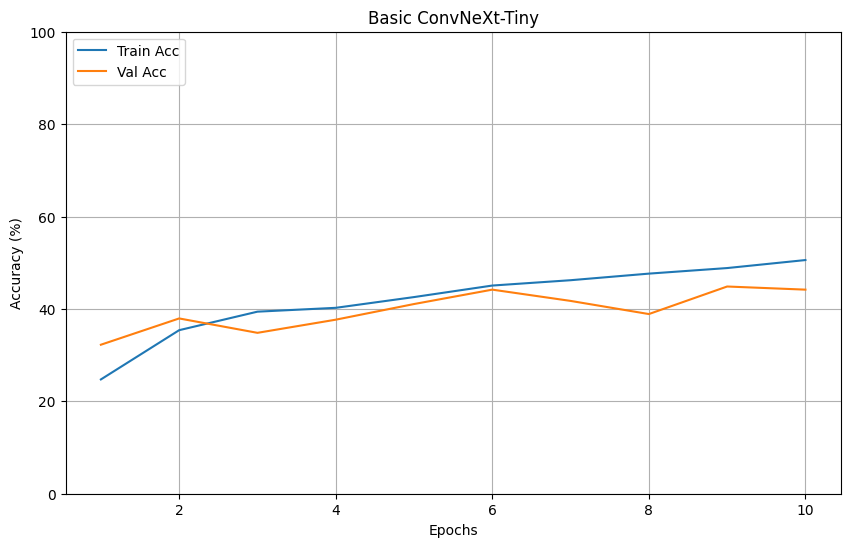


Final Test Accuracy: 44.10%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Basic ConvNeXt-Tiny")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ConvNeXt-Tiny

- Using a pretrained model
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 41.75% | Val: 44.72% | LR: 0.000100
Epoch 2/10 | Train: 56.40% | Val: 54.61% | LR: 0.000100
Epoch 3/10 | Train: 64.58% | Val: 54.47% | LR: 0.000100
Epoch 4/10 | Train: 71.54% | Val: 55.15% | LR: 0.000100
Epoch 5/10 | Train: 80.49% | Val: 54.07% | LR: 0.000100
Epoch 6/10 | Train: 88.73% | Val: 53.79% | LR: 0.000100
Epoch 7/10 | Train: 91.14% | Val: 56.10% | LR: 0.000100
Epoch 8/10 | Train: 95.99% | Val: 55.01% | LR: 0.000100
Epoch 9/10 | Train: 94.82% | Val: 55.96% | LR: 0.000100
Epoch 10/10 | Train: 97.37% | Val: 58.13% | LR: 0.000100


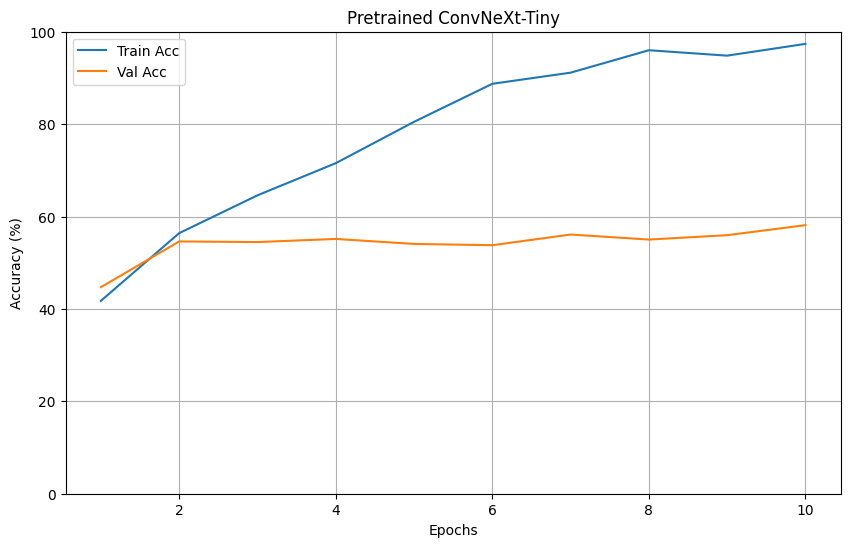


Final Test Accuracy: 61.06%


In [8]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ConvNeXt-Tiny")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ConvNeXt-Tiny with regularization

- Using a pretrained model
- Using augmentation and regularization
- No LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/15 | Train: 22.90% | Val: 34.82% | LR: 0.000100
Epoch 2/15 | Train: 37.56% | Val: 36.59% | LR: 0.000100
Epoch 3/15 | Train: 44.48% | Val: 45.53% | LR: 0.000100
Epoch 4/15 | Train: 49.44% | Val: 45.53% | LR: 0.000100
Epoch 5/15 | Train: 49.88% | Val: 45.66% | LR: 0.000100
Epoch 6/15 | Train: 50.65% | Val: 50.68% | LR: 0.000100
Epoch 7/15 | Train: 52.44% | Val: 47.43% | LR: 0.000100
Epoch 8/15 | Train: 55.21% | Val: 50.41% | LR: 0.000100
Epoch 9/15 | Train: 55.96% | Val: 49.32% | LR: 0.000100
Epoch 10/15 | Train: 56.64% | Val: 51.90% | LR: 0.000100
Epoch 11/15 | Train: 58.01% | Val: 49.59% | LR: 0.000100
Epoch 12/15 | Train: 58.78% | Val: 52.57% | LR: 0.000100
Epoch 13/15 | Train: 59.80% | Val: 51.90% | LR: 0.000100
Epoch 14/15 | Train: 60.92% | Val: 52.98% | LR: 0.000100
Epoch 15/15 | Train: 61.92% | Val: 50.68% | LR: 0.000100


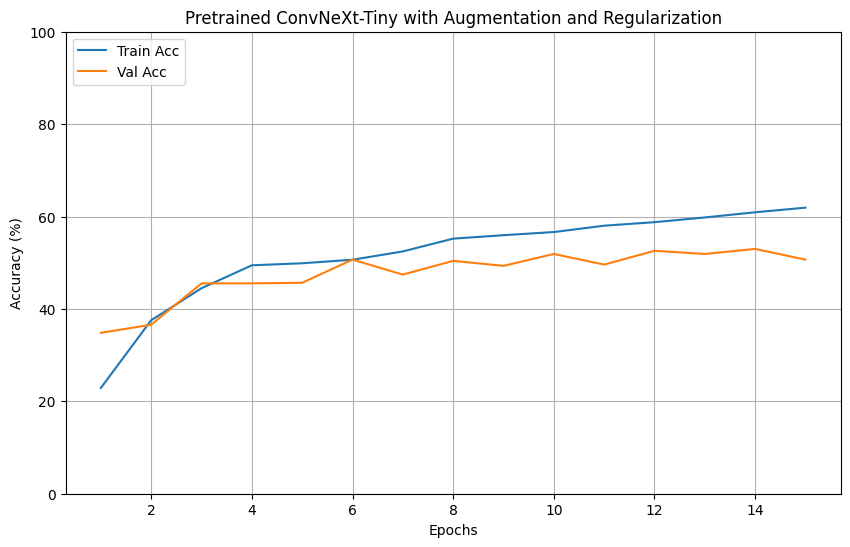


Final Test Accuracy: 59.95%


In [6]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=15)

plot_history(history, "Pretrained ConvNeXt-Tiny with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

### ConvNeXt-Tiny final version (using everything)

- Using a pretrained model
- Using augmentation and regularization
- Using LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/30 | Train: 31.48% | Val: 41.46% | LR: 0.000100
Epoch 2/30 | Train: 43.07% | Val: 46.07% | LR: 0.000100
Epoch 3/30 | Train: 47.44% | Val: 47.43% | LR: 0.000100
Epoch 4/30 | Train: 51.00% | Val: 46.34% | LR: 0.000100
Epoch 5/30 | Train: 52.36% | Val: 55.01% | LR: 0.000100
Epoch 6/30 | Train: 54.55% | Val: 50.00% | LR: 0.000100
Epoch 7/30 | Train: 56.33% | Val: 50.14% | LR: 0.000100
Epoch 8/30 | Train: 56.59% | Val: 55.15% | LR: 0.000100
Epoch 9/30 | Train: 59.03% | Val: 54.34% | LR: 0.000100
Epoch 10/30 | Train: 60.42% | Val: 54.74% | LR: 0.000100
Epoch 11/30 | Train: 61.58% | Val: 52.85% | LR: 0.000050
Epoch 12/30 | Train: 65.77% | Val: 54.88% | LR: 0.000050
Epoch 13/30 | Train: 67.23% | Val: 54.07% | LR: 0.000050
Epoch 14/30 | Train: 67.79% | Val: 54.47% | LR: 0.000025
Epoch 15/30 | Train: 71.12% | Val: 55.69% | LR: 0.000025
Epoch 16/30 | Train: 72.07% | Val: 57.45% | LR: 0.000025
Epoch 17/30 | Train: 74.11% | Val: 55.15% | LR: 0.000025
Epoch 18/30 | Train: 74.06% | Val: 54.47

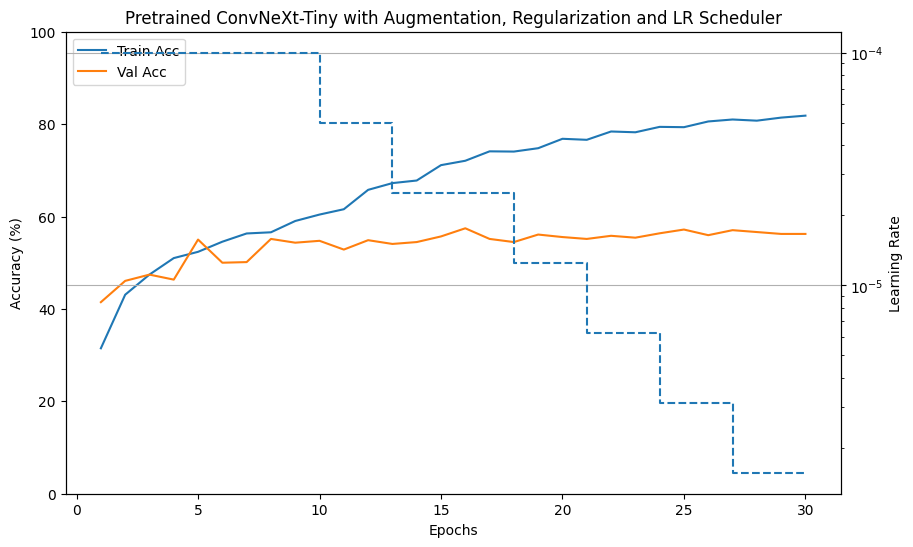


Final Test Accuracy: 64.13%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.3, # DECREASED FROM 0.5 TO 0.3
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30 # INCREASED TO 30
)

plot_history(history, "Pretrained ConvNeXt-Tiny with Augmentation, Regularization and LR Scheduler")

test_accuracy = evaluate_model(model, test_loader)